# Dataset description
## CPI by city
**Source**: DANE

**Download**: [Banco de la República](https://suameca.banrep.gov.co/estadisticas-economicas/tablasPreconstruidas)

# Code

## Imports

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [9]:
cities_names = [
    "Bucaramanga",
    "Armenia",
    "Tunja",
    "Ibagué",
    "Pereira",
    "Total_Nacional",
] 

dfs = []
for name in cities_names:
    path = f"./data/{name}.csv"
    a = pd.read_csv(path, encoding="utf-8")
    dfs.append(a)

## Cleaning

In [10]:
cities_names = [
    "Bucaramanga",
    "Armenia",
    "Tunja",
    "Ibagué",
    "Pereira",
    "National",
] 

cln_dfs = []
for i, df in enumerate(dfs):
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df.set_index("Fecha", inplace=True)
    df = df[df.index.year == 2026]
    df = df[["Variación año corrido (%)"]]
    df = df.rename(columns={"Variación año corrido (%)": cities_names[i]})

    cln_dfs.append(df)

## Combine

In [11]:
df = pd.concat(cln_dfs, axis=1)
april = df.loc[df.index.max()]
april = april.sort_values()

## Plot

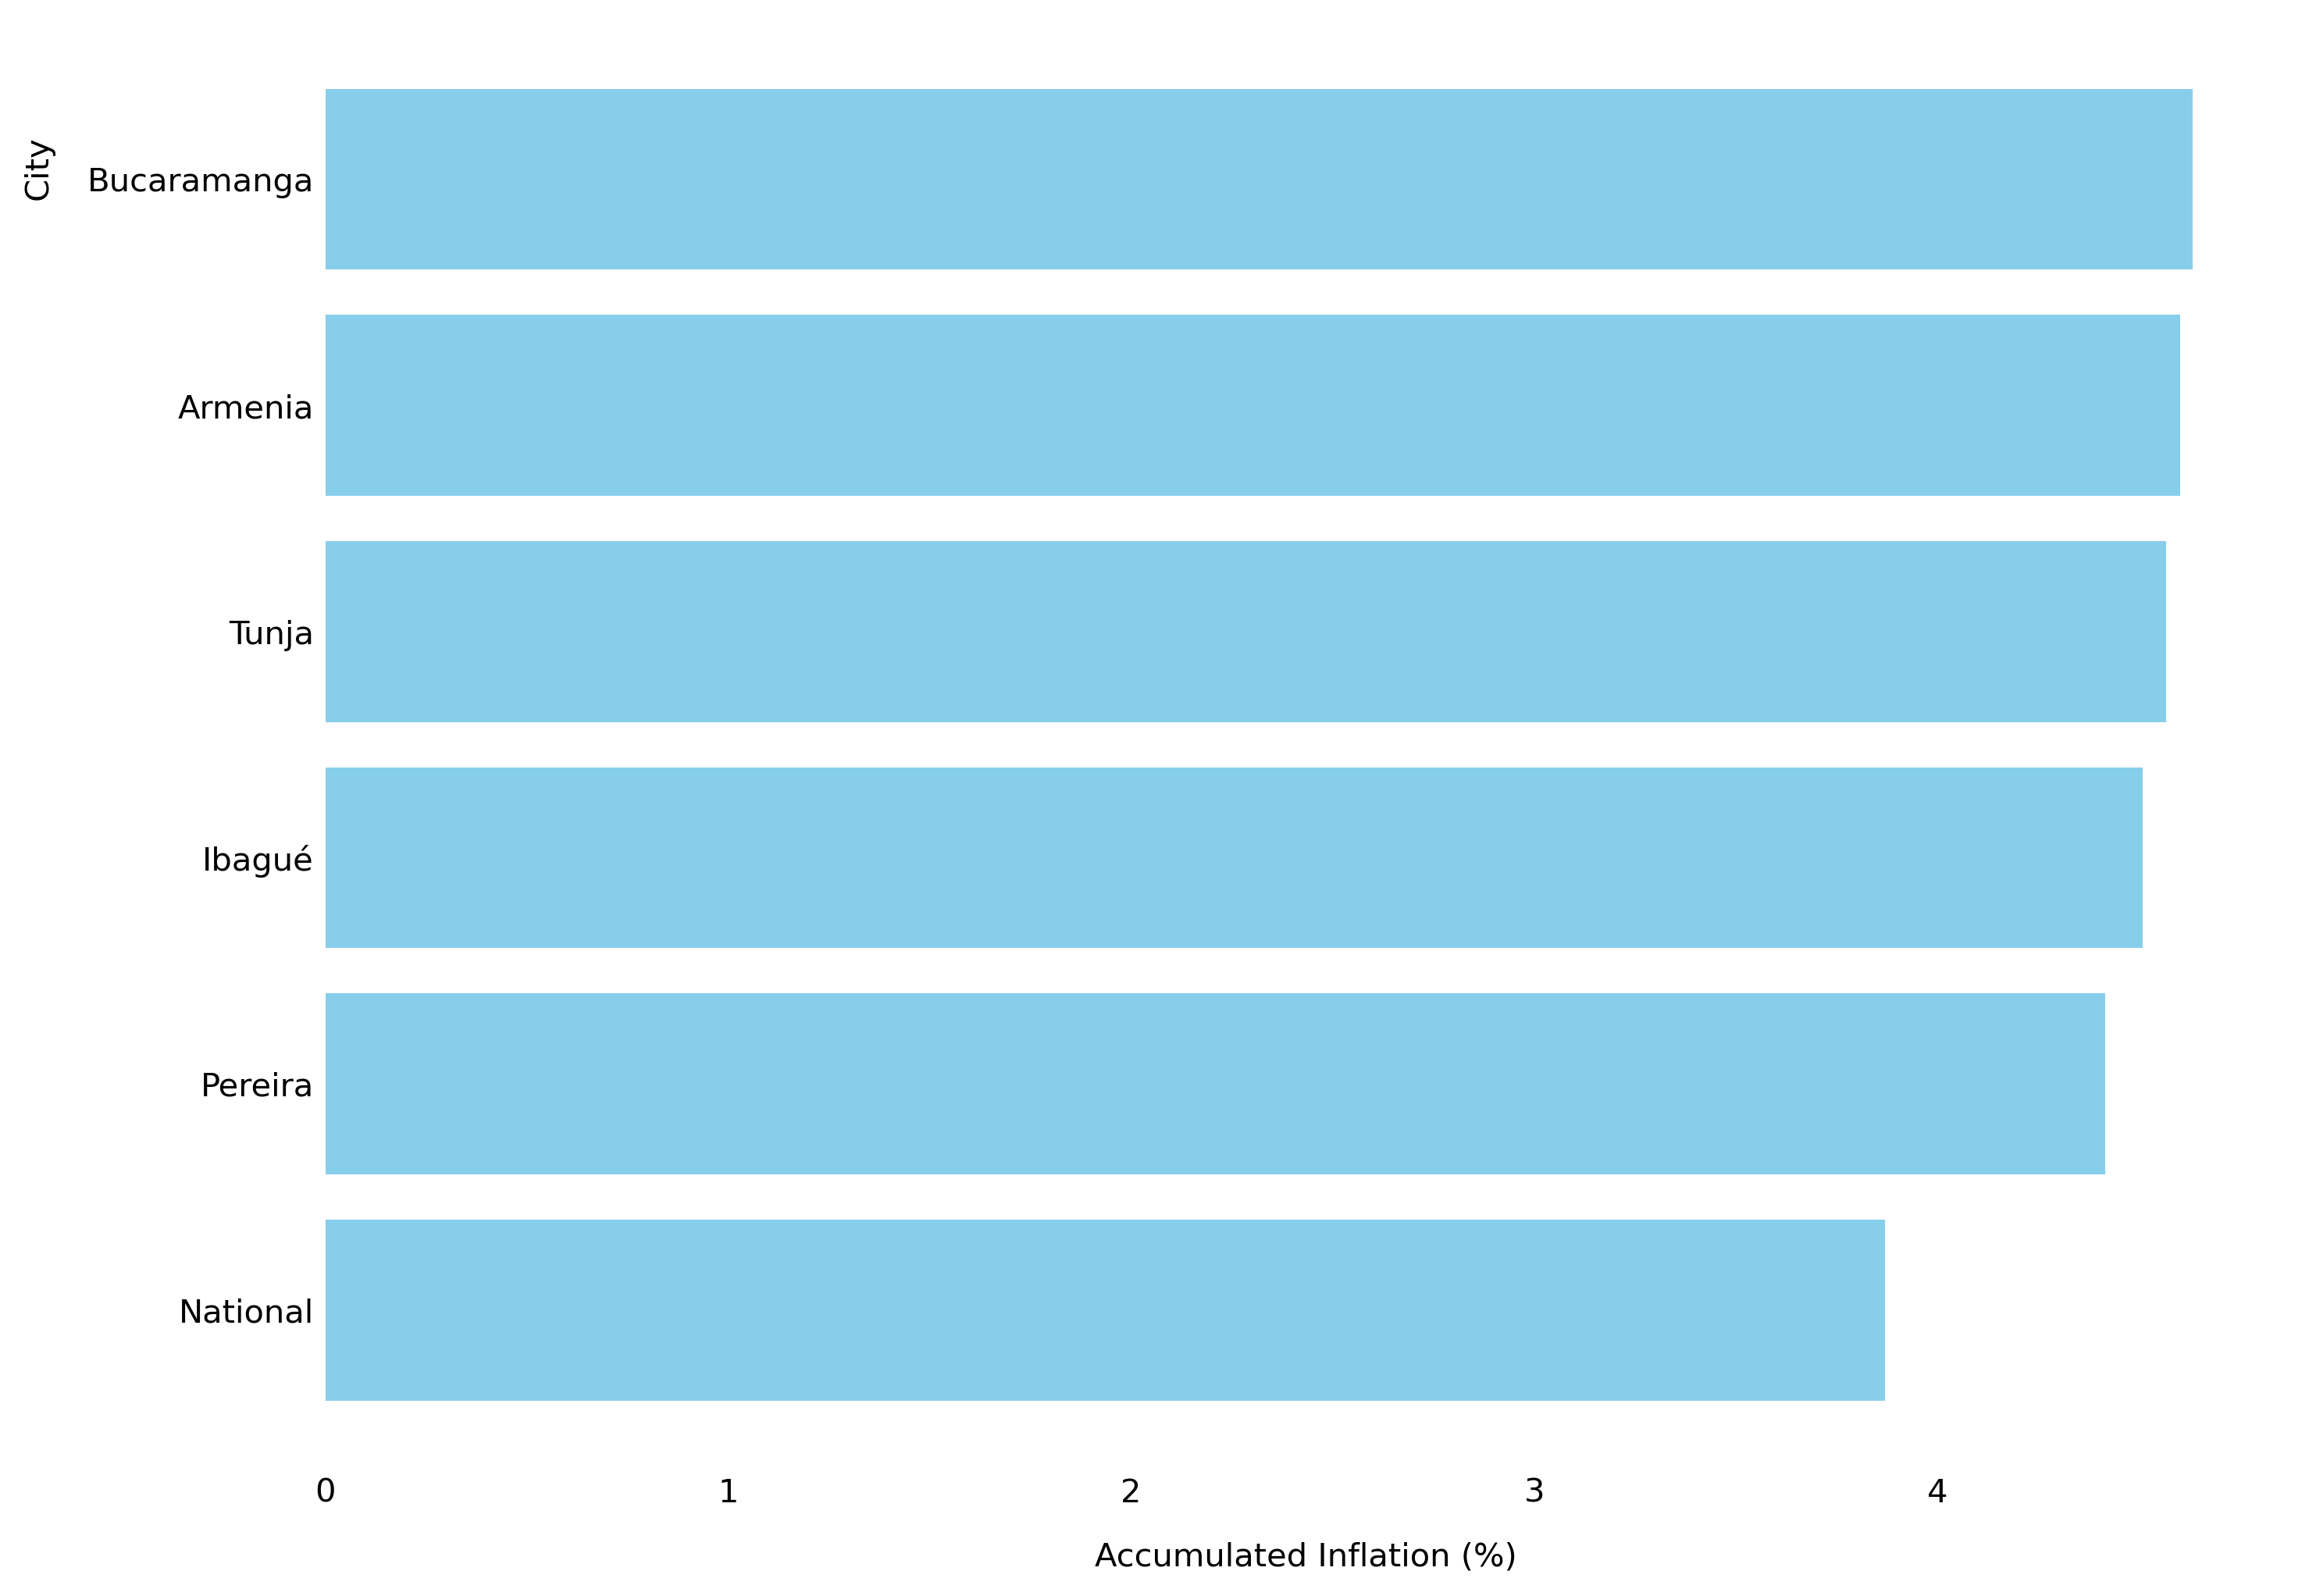

In [12]:
plt.figure(figsize=(10.8, 8), dpi=300)

plt.barh(april.index, april.values, color="skyblue")

plt.tick_params(axis="x", length=0)
plt.tick_params(axis="y", length=0)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

plt.ylabel("City", labelpad=10, y=0.9)
plt.xlabel("Accumulated Inflation (%)", labelpad=10)

plt.show()